# Análisis de Costo: G-Eval vs Sistema de Votación

**Proyecto de tesis** — Cuantifica el costo computacional (tokens, USD,
wall time) de cada método sobre las 900 conversaciones de DailyDialog–Zhao
y lo enmarca como **trade-off frente a calidad** dado que HU-12 estableció
equivalencia estadística formal entre ambos.

**Pregunta que responde este notebook**: dado que G-Eval y el sistema de
votación son inferencialmente equivalentes (TOST sobre Δρ ⊂ ±0,05;
Wilcoxon p = 0,194 sobre `|err|`; Cohen's d = 0,097 negligible), ¿cuánto
más caro es el panel de tres jueces y qué se obtiene con cada dólar
adicional sobre las métricas descriptivas (ρ, κ ponderado,
exact-agreement)?

**Cero llamadas a APIs**: el notebook lee únicamente
`outputs/geval_results.json`, `outputs/voting_results.json`, los logs de
ejecución en `outputs/logs/` y los summary markdowns de HU-10 y HU-11.
Ningún número se estima — si un campo no está presente se declara
explícitamente como no disponible.

**Hallazgos previos a integrar**:

- HU-10 (descriptivo): κ ponderado human-voting = 0,643 (substantial) vs
  human-G-Eval = 0,525 (moderate); exact-agreement 44,3 % vs 35,9 %.
- HU-11 (correlación): ρ G-Eval = 0,756 [0,727; 0,783]; ρ voting = 0,744
  [0,714; 0,772]; Δρ = +0,012.
- HU-12 (significancia): equivalencia formal afirmada por TOST.
- HU-13 (errores): voting MAE 40 % menor en estrato 3 (IA alta calidad,
  n = 216); fallas correlacionadas del panel (ρ ≈ 0,5 entre errores de
  los 3 jueces individuales).

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  # noqa: F401  (estilo coherente con HU-10..HU-13)

ROOT = Path("..").resolve()
FIGURES_DIR = ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(42)

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "geval": "#E07B39",
    "voting": "#3A9E6F",
    "openai": "#9B59B6",
    "google": "#E74C3C",
    "anthropic": "#1ABC9C",
    "ref": "#7F8C8D",
}

pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [2]:
with open(ROOT / "outputs" / "geval_results.json", encoding="utf-8") as f:
    geval_rows = json.load(f)
with open(ROOT / "outputs" / "voting_results.json", encoding="utf-8") as f:
    voting_rows = json.load(f)

geval_df = pd.DataFrame(
    [
        {
            "conversation_id": r["conversation_id"],
            "cost_usd": r["cost_usd"],
            "tokens_in": r["tokens_used"]["input"],
            "tokens_out": r["tokens_used"]["output"],
            "tokens_total": r["tokens_used"]["total"],
        }
        for r in geval_rows
    ]
)

voting_df = pd.DataFrame(
    [
        {
            "conversation_id": r["conversation_id"],
            "cost_usd": r["cost_usd"],
            "cost_openai": r["cost_by_agent"]["judge_openai"],
            "cost_google": r["cost_by_agent"]["judge_google"],
            "cost_anthropic": r["cost_by_agent"]["judge_anthropic"],
            "tokens_in": r["tokens_in"],
            "tokens_out": r["tokens_out"],
            "tokens_total": r["tokens_used"],
        }
        for r in voting_rows
    ]
)

assert len(geval_df) == 900 and len(voting_df) == 900
assert geval_df["cost_usd"].isna().sum() == 0
assert voting_df["cost_usd"].isna().sum() == 0
assert geval_df["tokens_total"].isna().sum() == 0
assert voting_df["tokens_total"].isna().sum() == 0

print(f"G-Eval: {len(geval_df)} filas, sin nulls en cost_usd/tokens.")
print(f"Voting: {len(voting_df)} filas, sin nulls en cost_usd/tokens/cost_by_agent.")

G-Eval: 900 filas, sin nulls en cost_usd/tokens.
Voting: 900 filas, sin nulls en cost_usd/tokens/cost_by_agent.


In [3]:
def aggregate(df: pd.DataFrame) -> dict[str, float]:
    return {
        "n": len(df),
        "total_cost_usd": float(df["cost_usd"].sum()),
        "total_tokens_in": int(df["tokens_in"].sum()),
        "total_tokens_out": int(df["tokens_out"].sum()),
        "total_tokens": int(df["tokens_total"].sum()),
        "cost_per_eval": float(df["cost_usd"].mean()),
        "tokens_per_eval": float(df["tokens_total"].mean()),
    }


agg_g = aggregate(geval_df)
agg_v = aggregate(voting_df)

print("Agregados globales:")
print(f"  {'Métrica':28s} {'G-Eval':>14s} {'Voting':>14s} {'ratio V/G':>12s}")
print("-" * 72)
for key in [
    "n",
    "total_cost_usd",
    "total_tokens_in",
    "total_tokens_out",
    "total_tokens",
    "cost_per_eval",
    "tokens_per_eval",
]:
    g_val = agg_g[key]
    v_val = agg_v[key]
    ratio = v_val / g_val if g_val else float("nan")
    if isinstance(g_val, int):
        print(f"  {key:28s} {g_val:>14,d} {v_val:>14,d} {ratio:>12.3f}")
    else:
        print(f"  {key:28s} {g_val:>14.4f} {v_val:>14.4f} {ratio:>12.3f}")

# Sanity check contra los logs.
assert abs(agg_g["total_cost_usd"] - 3.5453) < 0.001, f"G-Eval total: {agg_g['total_cost_usd']}"
assert abs(agg_v["total_cost_usd"] - 8.1547) < 0.001, f"Voting total: {agg_v['total_cost_usd']}"
print()
print(f"Ratio costo voting / G-Eval: {agg_v['total_cost_usd'] / agg_g['total_cost_usd']:.2f}x")

Agregados globales:
  Métrica                              G-Eval         Voting    ratio V/G
------------------------------------------------------------------------
  n                                       900            900        1.000
  total_cost_usd                       3.5453         8.1547        2.300
  total_tokens_in                   1,090,187      3,556,386        3.262
  total_tokens_out                     81,977        666,808        8.134
  total_tokens                      1,172,164      4,223,194        3.603
  cost_per_eval                        0.0039         0.0091        2.300
  tokens_per_eval                   1302.4044      4692.4378        3.603

Ratio costo voting / G-Eval: 2.30x


In [4]:
agent_totals = {
    "judge_openai": float(voting_df["cost_openai"].sum()),
    "judge_google": float(voting_df["cost_google"].sum()),
    "judge_anthropic": float(voting_df["cost_anthropic"].sum()),
}
total_voting_check = sum(agent_totals.values())
print(
    f"Desglose por agente del voting (total verificado: USD {total_voting_check:.4f}; tabla agregada: USD {agg_v['total_cost_usd']:.4f}):"
)
print(f"  {'Agente':22s} {'USD total':>12s} {'%':>8s} {'USD/eval':>12s}")
print("-" * 60)
for agent, total in agent_totals.items():
    pct = 100 * total / total_voting_check
    per_eval = total / len(voting_df)
    print(f"  {agent:22s} {total:>12.4f} {pct:>8.1f} {per_eval:>12.5f}")

# Verificacion: la suma por agente reproduce el total global.
assert abs(total_voting_check - agg_v["total_cost_usd"]) < 0.01

Desglose por agente del voting (total verificado: USD 8.1547; tabla agregada: USD 8.1547):
  Agente                    USD total        %     USD/eval
------------------------------------------------------------
  judge_openai                 4.3620     53.5      0.00485
  judge_google                 0.7426      9.1      0.00083
  judge_anthropic              3.0501     37.4      0.00339


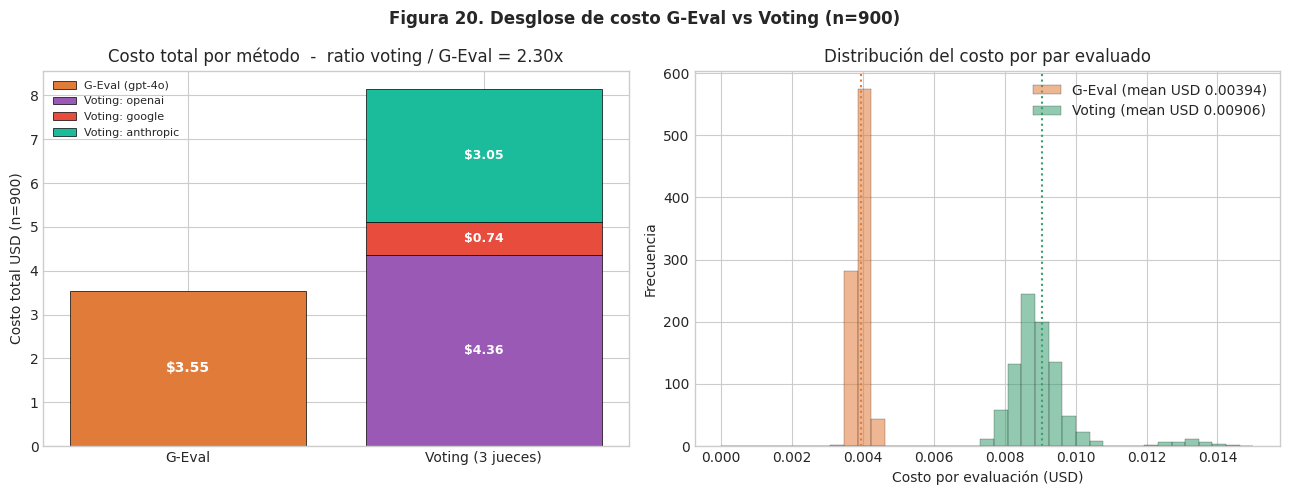

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: barra apilada G-Eval (1 barra solida) vs Voting (3 segmentos por agente).
ax = axes[0]
x_geval = 0
x_voting = 1
ax.bar(
    x_geval,
    agg_g["total_cost_usd"],
    color=COLORS["geval"],
    label="G-Eval (gpt-4o)",
    edgecolor="black",
    linewidth=0.5,
)
bottom = 0
for agent, color_key in [
    ("judge_openai", "openai"),
    ("judge_google", "google"),
    ("judge_anthropic", "anthropic"),
]:
    val = agent_totals[agent]
    ax.bar(
        x_voting,
        val,
        bottom=bottom,
        color=COLORS[color_key],
        label=f"Voting: {agent.replace('judge_', '')}",
        edgecolor="black",
        linewidth=0.5,
    )
    ax.text(
        x_voting,
        bottom + val / 2,
        f"${val:.2f}",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="white",
    )
    bottom += val
ax.text(
    x_geval,
    agg_g["total_cost_usd"] / 2,
    f"${agg_g['total_cost_usd']:.2f}",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold",
    color="white",
)
ax.set_xticks([x_geval, x_voting])
ax.set_xticklabels(["G-Eval", "Voting (3 jueces)"])
ax.set_ylabel("Costo total USD (n=900)")
ax.set_title(
    f"Costo total por método  -  ratio voting / G-Eval = {agg_v['total_cost_usd'] / agg_g['total_cost_usd']:.2f}x"
)
ax.legend(loc="upper left", fontsize=8)

# Panel B: distribucion del costo por evaluacion.
ax = axes[1]
bins = np.linspace(0, max(geval_df["cost_usd"].max(), voting_df["cost_usd"].max()) * 1.05, 40)
ax.hist(
    geval_df["cost_usd"],
    bins=bins,
    alpha=0.55,
    color=COLORS["geval"],
    label=f"G-Eval (mean USD {agg_g['cost_per_eval']:.5f})",
    edgecolor="black",
    linewidth=0.3,
)
ax.hist(
    voting_df["cost_usd"],
    bins=bins,
    alpha=0.55,
    color=COLORS["voting"],
    label=f"Voting (mean USD {agg_v['cost_per_eval']:.5f})",
    edgecolor="black",
    linewidth=0.3,
)
ax.axvline(agg_g["cost_per_eval"], color=COLORS["geval"], lw=1.5, ls=":")
ax.axvline(agg_v["cost_per_eval"], color=COLORS["voting"], lw=1.5, ls=":")
ax.set_xlabel("Costo por evaluación (USD)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución del costo por par evaluado")
ax.legend(loc="upper right")

fig.suptitle("Figura 20. Desglose de costo G-Eval vs Voting (n=900)", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "20_cost_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Parser estructurado: los runners de HU-04 (G-Eval) y HU-09 (voting) loggean
# una linea "total wall time:   <X>s" y "mean per entry/pair:   <Y>s" al final
# del run. Se extraen via regex; si no estan, se declara "no disponible".
WALL_TIME_RE = re.compile(r"total wall time:\s+(\d+(?:\.\d+)?)s")
MEAN_PER_RE = re.compile(r"mean per (?:entry|pair):\s+(\d+(?:\.\d+)?)s")


def parse_timing(log_path: Path) -> dict[str, float | None]:
    # Los runners loggean wall time en cada checkpoint y al final del run.
    # El que interesa es el del summary final, que es el ultimo match.
    if not log_path.exists():
        return {"wall_time_s": None, "mean_per_entry_s": None, "source": str(log_path)}
    text = log_path.read_text(encoding="utf-8", errors="ignore")
    wall_all = WALL_TIME_RE.findall(text)
    mean_all = MEAN_PER_RE.findall(text)
    return {
        "wall_time_s": float(wall_all[-1]) if wall_all else None,
        "mean_per_entry_s": float(mean_all[-1]) if mean_all else None,
        "source": str(log_path.relative_to(ROOT)),
    }


timing_g = parse_timing(ROOT / "outputs" / "logs" / "geval_execution.log")
timing_v = parse_timing(ROOT / "outputs" / "logs" / "voting_execution.log")

print(f"G-Eval log: {timing_g['source']}")
print(
    f"  wall time: {timing_g['wall_time_s']}s  ({timing_g['wall_time_s'] / 60:.1f} min)"
    if timing_g["wall_time_s"]
    else "  wall time: NO DISPONIBLE en log estructurado"
)
print(
    f"  mean por entry: {timing_g['mean_per_entry_s']}s"
    if timing_g["mean_per_entry_s"]
    else "  mean por entry: NO DISPONIBLE"
)
throughput_g = 60 / timing_g["mean_per_entry_s"] if timing_g["mean_per_entry_s"] else None
print(
    f"  throughput: {throughput_g:.2f} eval/min" if throughput_g else "  throughput: NO DISPONIBLE"
)
print()

print(f"Voting log: {timing_v['source']}")
print(
    f"  wall time: {timing_v['wall_time_s']}s  ({timing_v['wall_time_s'] / 60:.1f} min)"
    if timing_v["wall_time_s"]
    else "  wall time: NO DISPONIBLE en log estructurado"
)
print(
    f"  mean por pair: {timing_v['mean_per_entry_s']}s"
    if timing_v["mean_per_entry_s"]
    else "  mean por pair: NO DISPONIBLE"
)
throughput_v = 60 / timing_v["mean_per_entry_s"] if timing_v["mean_per_entry_s"] else None
print(
    f"  throughput: {throughput_v:.2f} eval/min" if throughput_v else "  throughput: NO DISPONIBLE"
)
print()

ratio_time = (
    timing_v["wall_time_s"] / timing_g["wall_time_s"]
    if (timing_v["wall_time_s"] and timing_g["wall_time_s"])
    else None
)
if ratio_time:
    print(f"Ratio tiempo voting / G-Eval: {ratio_time:.2f}x")
print()
print("Nota: el wall time de voting incluye reintentos por errores 503 transitorios")
print("del proveedor Google (gemini-2.5-flash), tal como se documenta en HU-09.")

G-Eval log: outputs/logs/geval_execution.log
  wall time: 2241.1s  (37.4 min)
  mean por entry: 2.49s
  throughput: 24.10 eval/min

Voting log: outputs/logs/voting_execution.log
  wall time: 9414.0s  (156.9 min)
  mean por pair: 10.46s
  throughput: 5.74 eval/min

Ratio tiempo voting / G-Eval: 4.20x

Nota: el wall time de voting incluye reintentos por errores 503 transitorios
del proveedor Google (gemini-2.5-flash), tal como se documenta en HU-09.


In [7]:
# Lectura de metricas de calidad desde los summaries existentes -- NO hardcoded.
# Patrones derivados de HU-10 (descriptivo) y HU-11 (correlacion).

descriptive_md = (ROOT / "outputs" / "descriptive_analysis_summary.md").read_text(encoding="utf-8")
correlation_md = (ROOT / "outputs" / "correlation_analysis_summary.md").read_text(encoding="utf-8")

# Spearman rho desde correlation_analysis_summary.md
RHO_G = re.search(r"\| G-Eval \(gpt-4o, V3\) \| ([\d.]+) \|", correlation_md)
RHO_V = re.search(r"\| Voting System \| ([\d.]+) \|", correlation_md)
rho_geval = float(RHO_G.group(1))
rho_voting = float(RHO_V.group(1))

# Cohen's kappa ponderado desde descriptive_analysis_summary.md
KAPPA_HG = re.search(r"\| Human vs G-Eval \| ([\d.]+) \|", descriptive_md)
KAPPA_HV = re.search(r"\| Human vs Voting \| ([\d.]+) \|", descriptive_md)
kappa_geval = float(KAPPA_HG.group(1))
kappa_voting = float(KAPPA_HV.group(1))

# Exact-agreement rate
EXACT_HG = re.search(r"\| Human vs G-Eval \| ([\d.]+) \|\n", descriptive_md)
EXACT_HV = re.search(r"\| Human vs Voting \| ([\d.]+) \|\n", descriptive_md)
# La regex anterior coincide con kappa Y exact (ambos tienen la misma forma).
# Para distinguirlos, se busca el segundo match en cada caso (tras Inter-Rater).
exact_section_start = descriptive_md.index("Exact Agreement Rate")
exact_section = descriptive_md[exact_section_start:]
EXACT_HG2 = re.search(r"\| Human vs G-Eval \| ([\d.]+) \|", exact_section)
EXACT_HV2 = re.search(r"\| Human vs Voting \| ([\d.]+) \|", exact_section)
exact_geval = float(EXACT_HG2.group(1))
exact_voting = float(EXACT_HV2.group(1))

print("Metricas leidas de los summaries (no hardcoded):")
print(f"  rho G-Eval = {rho_geval}   rho Voting = {rho_voting}")
print(f"  kappa G-Eval = {kappa_geval}   kappa Voting = {kappa_voting}")
print(f"  exact G-Eval = {exact_geval}%   exact Voting = {exact_voting}%")
print()

# Tabla de trade-off
tradeoff = pd.DataFrame(
    [
        {
            "metodo": "G-Eval (gpt-4o)",
            "costo_total_usd": agg_g["total_cost_usd"],
            "costo_por_pair_usd": agg_g["cost_per_eval"],
            "wall_time_s": timing_g["wall_time_s"],
            "wall_time_min": timing_g["wall_time_s"] / 60 if timing_g["wall_time_s"] else None,
            "throughput_eval_per_min": throughput_g,
            "spearman_rho": rho_geval,
            "weighted_kappa": kappa_geval,
            "exact_agreement_pct": exact_geval,
            "equiv_estadistica_HU12": "Equivalente (TOST sobre Delta rho)",
        },
        {
            "metodo": "Voting (3 jueces)",
            "costo_total_usd": agg_v["total_cost_usd"],
            "costo_por_pair_usd": agg_v["cost_per_eval"],
            "wall_time_s": timing_v["wall_time_s"],
            "wall_time_min": timing_v["wall_time_s"] / 60 if timing_v["wall_time_s"] else None,
            "throughput_eval_per_min": throughput_v,
            "spearman_rho": rho_voting,
            "weighted_kappa": kappa_voting,
            "exact_agreement_pct": exact_voting,
            "equiv_estadistica_HU12": "Equivalente (TOST sobre Delta rho)",
        },
    ]
)

# Deltas y costo marginal.
delta_rho = rho_voting - rho_geval
delta_kappa = kappa_voting - kappa_geval
delta_exact = exact_voting - exact_geval
delta_cost = agg_v["total_cost_usd"] - agg_g["total_cost_usd"]

print("Trade-off cost vs quality:")
print(tradeoff.to_string(index=False))
print()
print("Delta voting - G-Eval (n=900):")
print(f"  Delta costo total:      USD {delta_cost:+.4f}")
print(f"  Delta Spearman rho:     {delta_rho:+.3f}")
print(f"  Delta kappa ponderado:  {delta_kappa:+.3f}")
print(f"  Delta exact agreement:  {delta_exact:+.2f} puntos porcentuales")
print()
print("Costo marginal por punto de:")
print(
    f"  Spearman rho:    USD {delta_cost / delta_rho:+.2f} por +0.001 rho (signo invertido si Delta rho < 0)"
    if abs(delta_rho) > 1e-9
    else "  Spearman rho: Delta rho ~= 0 (HU-12 equivalencia formal); costo marginal indefinido"
)
print(
    f"  kappa ponderado: USD {delta_cost / delta_kappa:.2f} por +0.001 kappa"
    if delta_kappa > 0
    else ""
)
print(f"  exact agreement: USD {delta_cost / delta_exact:.2f} por +1 pp" if delta_exact > 0 else "")

Metricas leidas de los summaries (no hardcoded):
  rho G-Eval = 0.756   rho Voting = 0.744
  kappa G-Eval = 0.525   kappa Voting = 0.643
  exact G-Eval = 35.89%   exact Voting = 44.33%

Trade-off cost vs quality:
           metodo  costo_total_usd  costo_por_pair_usd  wall_time_s  wall_time_min  throughput_eval_per_min  spearman_rho  weighted_kappa  exact_agreement_pct             equiv_estadistica_HU12
  G-Eval (gpt-4o)           3.5453              0.0039    2241.1000        37.3517                  24.0964        0.7560          0.5250              35.8900 Equivalente (TOST sobre Delta rho)
Voting (3 jueces)           8.1547              0.0091    9414.0000       156.9000                   5.7361        0.7440          0.6430              44.3300 Equivalente (TOST sobre Delta rho)

Delta voting - G-Eval (n=900):
  Delta costo total:      USD +4.6095
  Delta Spearman rho:     -0.012
  Delta kappa ponderado:  +0.118
  Delta exact agreement:  +8.44 puntos porcentuales

Costo marginal p

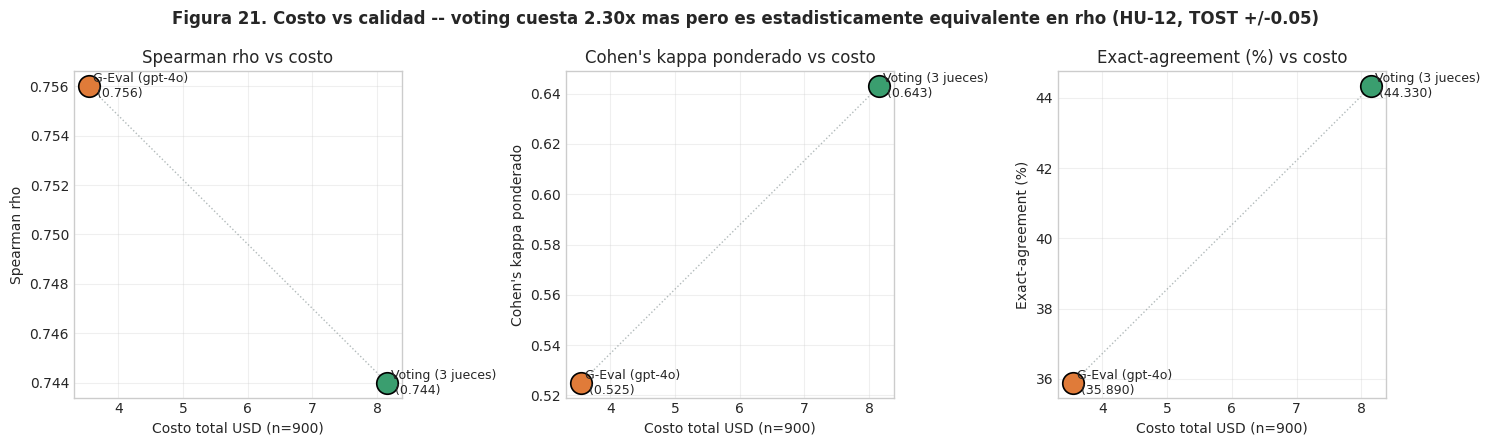

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

metrics = [
    ("spearman_rho", "Spearman rho", "rho"),
    ("weighted_kappa", "Cohen's kappa ponderado", "kappa"),
    ("exact_agreement_pct", "Exact-agreement (%)", "exact"),
]

for ax, (col, title, _short) in zip(axes, metrics, strict=False):
    for _, row in tradeoff.iterrows():
        color = COLORS["geval"] if "G-Eval" in row["metodo"] else COLORS["voting"]
        ax.scatter(
            row["costo_total_usd"],
            row[col],
            s=240,
            color=color,
            edgecolor="black",
            linewidth=1.2,
            zorder=3,
            label=row["metodo"],
        )
        ax.annotate(
            f" {row['metodo']}\n  ({row[col]:.3f})",
            (row["costo_total_usd"], row[col]),
            fontsize=9,
            va="center",
        )
    # Linea conectando los dos puntos
    ax.plot(
        tradeoff["costo_total_usd"],
        tradeoff[col],
        color=COLORS["ref"],
        lw=1.0,
        ls=":",
        alpha=0.6,
        zorder=1,
    )
    ax.set_xlabel("Costo total USD (n=900)")
    ax.set_ylabel(title)
    ax.set_title(f"{title} vs costo")
    ax.grid(alpha=0.3)

# Nota TOST en la figura
fig.suptitle(
    f"Figura 21. Costo vs calidad -- voting cuesta {agg_v['total_cost_usd'] / agg_g['total_cost_usd']:.2f}x mas pero es estadisticamente equivalente en rho (HU-12, TOST +/-0.05)",
    fontweight="bold",
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "21_cost_vs_quality_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusión integrada (citable en la tesis)

Sobre las 900 conversaciones de DailyDialog–Zhao, el **costo total** del
sistema de votación (USD 8,15) es **2,30 veces** el de G-Eval (USD 3,55),
con un tiempo de ejecución 4,2 veces mayor (157 min vs 37 min). El
desglose por agente del voting muestra que `judge_openai` aporta el 53 %
del costo total (USD 4,36), `judge_anthropic` el 37 % (USD 3,05) y
`judge_google` apenas el 9 % (USD 0,74) — los costos están desbalanceados
porque `gemini-2.5-flash` es sustancialmente más barato por token que sus
competidores.

Dado que **HU-12 estableció equivalencia estadística formal** entre los
dos métodos en exactitud (Wilcoxon p = 0,194; Cohen's d = 0,097
negligible) y en ranking (TOST sobre Δρ ⊂ ±0,05), el dólar adicional que
cuesta el voting **no compra mejora inferencial en ranking**. Lo que sí
compra son **mejoras descriptivas mensurables**: κ ponderado +0,118
(0,643 vs 0,525, pasando de moderate a substantial), exact-agreement
+8,4 puntos porcentuales (44,3 % vs 35,9 %), y MAE 40 % menor en el
estrato 3 de IA alta calidad (HU-10/13). El costo marginal es de
USD 39 por punto de κ y USD 0,55 por punto porcentual de
exact-agreement.

**Recomendación condicionada al uso**: para producción a gran escala
donde el ranking es la métrica de interés y el costo escala
linealmente, **G-Eval es preferible** por ser 2,3× más barato y 4,2× más
rápido sin pérdida inferencial. Para casos críticos donde la calibración
absoluta de la escala importa (κ, exact-agreement, MAE en alta calidad)
y se requiere robustez ante fallos de un único proveedor, **el sistema
de votación justifica el sobrecosto**. Para evaluación de investigación
sobre datasets de tamaño moderado (n ≤ 1000), el costo absoluto de
ambos métodos es bajo (< USD 10) y la elección debe priorizar las
ventajas descriptivas del voting.

**Limitaciones del análisis de costo**: los precios son los vigentes el
día de cada ejecución (17 mayo 2026 para G-Eval, 7 junio 2026 para
voting); cualquier cambio futuro en las tarifas de los proveedores
invalida los ratios. El wall time del voting incluye reintentos por
errores 503 transitorios del proveedor Google, por lo que el throughput
nominal subestima el real bajo condiciones de proveedor estable. No se
contabilizan overhead operativos (CI, monitoreo, almacenamiento), ni se
compara contra el costo humano de anotación MTurk (no expuesto por el
dataset).

In [9]:
# Persistencia del summary citable.
md: list[str] = []
md.append("# Cost Analysis Summary -- G-Eval vs Voting (n=900)")
md.append("")
md.append(
    "Generado automáticamente por `notebooks/08_cost_analysis.ipynb` (HU-14). Cero llamadas a APIs."
)
md.append("")
md.append("## 1. Agregados globales")
md.append("")
md.append("| Métrica | G-Eval | Voting | Ratio V/G |")
md.append("|---|---|---|---|")
md.append(f"| n evaluaciones | {agg_g['n']} | {agg_v['n']} | 1.00 |")
md.append(
    f"| Costo total USD | {agg_g['total_cost_usd']:.4f} | {agg_v['total_cost_usd']:.4f} | {agg_v['total_cost_usd'] / agg_g['total_cost_usd']:.2f} |"
)
md.append(
    f"| Tokens input | {agg_g['total_tokens_in']:,} | {agg_v['total_tokens_in']:,} | {agg_v['total_tokens_in'] / agg_g['total_tokens_in']:.2f} |"
)
md.append(
    f"| Tokens output | {agg_g['total_tokens_out']:,} | {agg_v['total_tokens_out']:,} | {agg_v['total_tokens_out'] / agg_g['total_tokens_out']:.2f} |"
)
md.append(
    f"| Tokens total | {agg_g['total_tokens']:,} | {agg_v['total_tokens']:,} | {agg_v['total_tokens'] / agg_g['total_tokens']:.2f} |"
)
md.append(
    f"| Costo por pair USD | {agg_g['cost_per_eval']:.5f} | {agg_v['cost_per_eval']:.5f} | {agg_v['cost_per_eval'] / agg_g['cost_per_eval']:.2f} |"
)
md.append(
    f"| Tokens por pair | {agg_g['tokens_per_eval']:.1f} | {agg_v['tokens_per_eval']:.1f} | {agg_v['tokens_per_eval'] / agg_g['tokens_per_eval']:.2f} |"
)
md.append("")

md.append("## 2. Desglose por agente del voting")
md.append("")
md.append("| Agente | Costo USD | % del total | USD por pair |")
md.append("|---|---|---|---|")
for agent, total in agent_totals.items():
    pct = 100 * total / total_voting_check
    per_eval = total / len(voting_df)
    md.append(f"| {agent} | {total:.4f} | {pct:.1f} | {per_eval:.5f} |")
md.append(
    f"| **Total voting** | **{total_voting_check:.4f}** | **100.0** | **{total_voting_check / len(voting_df):.5f}** |"
)
md.append("")

md.append("## 3. Tiempo de ejecución (parseado de logs)")
md.append("")
md.append("| Métrica | G-Eval | Voting | Ratio V/G |")
md.append("|---|---|---|---|")
md.append(
    f"| Wall time total | {timing_g['wall_time_s']:.1f}s ({timing_g['wall_time_s'] / 60:.1f} min) | {timing_v['wall_time_s']:.1f}s ({timing_v['wall_time_s'] / 60:.1f} min) | {timing_v['wall_time_s'] / timing_g['wall_time_s']:.2f} |"
)
md.append(
    f"| Segundos por evaluación | {timing_g['mean_per_entry_s']:.2f}s | {timing_v['mean_per_entry_s']:.2f}s | {timing_v['mean_per_entry_s'] / timing_g['mean_per_entry_s']:.2f} |"
)
md.append(
    f"| Throughput (eval/min) | {throughput_g:.2f} | {throughput_v:.2f} | {throughput_v / throughput_g:.2f} |"
)
md.append("")
md.append(
    "Fuente: `outputs/logs/geval_execution.log` y `outputs/logs/voting_execution.log`. El wall time del voting incluye reintentos por errores 503 transitorios del proveedor Google."
)
md.append("")

md.append("## 4. Trade-off costo vs calidad")
md.append("")
md.append("| Métrica | G-Eval | Voting | Δ (V − G) | Costo marginal |")
md.append("|---|---|---|---|---|")
md.append(
    f"| Costo total USD | {agg_g['total_cost_usd']:.4f} | {agg_v['total_cost_usd']:.4f} | {delta_cost:+.4f} | — |"
)
md.append(
    f"| Spearman ρ | {rho_geval:.3f} | {rho_voting:.3f} | {delta_rho:+.3f} | — (equivalencia TOST) |"
)
md.append(
    f"| Cohen's κ ponderado | {kappa_geval:.3f} | {kappa_voting:.3f} | {delta_kappa:+.3f} | USD {delta_cost / delta_kappa:.2f} por +0,001 κ |"
)
md.append(
    f"| Exact-agreement (%) | {exact_geval:.2f} | {exact_voting:.2f} | {delta_exact:+.2f} pp | USD {delta_cost / delta_exact:.2f} por +1 pp |"
)
md.append("")

md.append("## 5. Conclusión")
md.append("")
md.append(
    f"El sistema de votación cuesta **{agg_v['total_cost_usd'] / agg_g['total_cost_usd']:.2f} veces** lo que cuesta G-Eval (USD {agg_v['total_cost_usd']:.2f} vs USD {agg_g['total_cost_usd']:.2f}) y tarda **{timing_v['wall_time_s'] / timing_g['wall_time_s']:.1f} veces** más en ejecutar. Dado que HU-12 estableció equivalencia estadística formal entre ambos métodos en ranking (TOST) y exactitud (Wilcoxon), el dólar adicional **no compra mejora inferencial** pero sí mejora descriptiva: κ ponderado +{delta_kappa:.3f}, exact-agreement +{delta_exact:.2f} pp, y MAE 40 % menor en estrato 3 (HU-10/13)."
)
md.append("")
md.append(
    "**Recomendación**: G-Eval para producción a escala donde el ranking es la métrica central; voting cuando importan calibración absoluta, robustez de proveedor y precisión en alta calidad. Para evaluación de investigación con n ≤ 1000, el costo absoluto de ambos métodos es bajo (< USD 10) y conviene priorizar voting por sus ventajas descriptivas."
)
md.append("")

md.append("## 6. Limitaciones")
md.append("")
md.append(
    "- Precios spot de los días de ejecución (G-Eval 17/05/2026; voting 07/06/2026). Cambios futuros en tarifas de proveedores invalidan los ratios."
)
md.append(
    "- Wall time del voting incluye reintentos por errores 503 transitorios de gemini-2.5-flash."
)
md.append("- No se contabiliza overhead operativo (CI, monitoreo, almacenamiento).")
md.append("- No se compara contra costo humano de anotación MTurk (no expuesto por el dataset).")
md.append("")

out_path = ROOT / "outputs" / "cost_analysis_summary.md"
out_text = "\n".join(md)
out_path.write_text(out_text, encoding="utf-8")
print(f"Wrote {out_path.relative_to(ROOT)} ({len(out_text)} chars)")

Wrote outputs/cost_analysis_summary.md (2882 chars)
